In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

**Step 1 \- Data Import and Preprocessing**

1. **Dataset**&nbsp;  
   &nbsp;Load the dataset ([`Food_Delivery_Time_Prediction.csv`](https://drive.google.com/file/d/1gAJGXBob3zRpJkRWQhvf3a94PS6NhGjx/view?usp=sharing)).  
2. **Handle Missing Values**  
   &nbsp;Check for any missing or inconsistent values in columns such as `Distance`, `Delivery_Time`, etc. and decide how to handle them, either through imputation or deletion.

3. **Data Transformation**

   * **Encode Categorical Variables**: Use one-hot encoding or label encoding for variables like `Weather Conditions`, `Traffic Conditions`, `Vehicle Type`.  
   * **Normalize/Standardize Numeric Columns**: Normalize or standardize continuous features like `Distance`, `Delivery_sTime`, and `Order_Cost` for consistency.


In [22]:
df = pd.read_csv('Food_Delivery_Time_Prediction.csv')
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [23]:
df.columns

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='str')

In [24]:
df.isna().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [25]:
df['Customer_Location_lat'] = df['Customer_Location'].apply(lambda x: x.split(',')[0][1:]).astype(float)
df['Customer_Location_lon'] = df['Customer_Location'].apply(lambda x: x.split(',')[1][:-1]).astype(float)

df['Restaurant_Location_lat'] = df['Restaurant_Location'].apply(lambda x: x.split(',')[0][1:]).astype(float)
df['Restaurant_Location_lon'] = df['Restaurant_Location'].apply(lambda x: x.split(',')[1][:-1]).astype(float)

df.drop(columns=['Customer_Location', 'Restaurant_Location'], inplace=True)

df.head()



,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Customer_Location_lat,Customer_Location_lon,Restaurant_Location_lat,Restaurant_Location_lon
0,ORD0001,1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083
1,ORD0002,21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606
2,ORD0003,6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482
3,ORD0004,13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698
4,ORD0005,6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    str    
 1   Distance                    200 non-null    float64
 2   Weather_Conditions          200 non-null    str    
 3   Traffic_Conditions          200 non-null    str    
 4   Delivery_Person_Experience  200 non-null    int64  
 5   Order_Priority              200 non-null    str    
 6   Order_Time                  200 non-null    str    
 7   Vehicle_Type                200 non-null    str    
 8   Restaurant_Rating           200 non-null    float64
 9   Customer_Rating             200 non-null    float64
 10  Delivery_Time               200 non-null    float64
 11  Order_Cost                  200 non-null    float64
 12  Tip_Amount                  200 non-null    float64
 13  Customer_Location_lat       200 non-null    fl

In [27]:
df.drop(columns=['Order_ID'], inplace=True)

num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'string', 'str']).columns



In [28]:
print("Numerical columns:")
print(num_cols)
print("\nCategorical columns:")
print(cat_cols)

Numerical columns:
Index(['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
       'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount',
       'Customer_Location_lat', 'Customer_Location_lon',
       'Restaurant_Location_lat', 'Restaurant_Location_lon'],
      dtype='str')

Categorical columns:
Index(['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type'],
      dtype='str')


In [29]:
ohe = OneHotEncoder()
st = StandardScaler()

transformation_pipeline = ColumnTransformer([
    ('ohe', ohe, cat_cols),
    ('st', st, num_cols)
], remainder='passthrough')


In [30]:
df_transformed = transformation_pipeline.fit_transform(df)

In [31]:
df_transformed_columns = transformation_pipeline.get_feature_names_out()
df_transformed = pd.DataFrame(df_transformed, columns=df_transformed_columns)

df_transformed.head()

,ohe__Weather_Conditions_Cloudy,ohe__Weather_Conditions_Rainy,ohe__Weather_Conditions_Snowy,ohe__Weather_Conditions_Sunny,ohe__Traffic_Conditions_High,ohe__Traffic_Conditions_Low,ohe__Traffic_Conditions_Medium,ohe__Order_Priority_High,ohe__Order_Priority_Low,ohe__Order_Priority_Medium,...,st__Delivery_Person_Experience,st__Restaurant_Rating,st__Customer_Rating,st__Delivery_Time,st__Order_Cost,st__Tip_Amount,st__Customer_Location_lat,st__Customer_Location_lon,st__Restaurant_Location_lat,st__Restaurant_Location_lon
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,-0.456512,0.515500,-0.987317,-1.487932,0.501852,1.192403,0.010590,-0.870096,-1.524861,0.768779
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.004325,1.085900,0.738511,-0.264987,-1.634294,-0.600810,-0.517739,1.323456,-0.883228,-1.694334
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.369535,-0.625302,-0.412041,-0.741529,1.092646,0.599332,-0.424182,0.448613,1.031355,-0.162109
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-1.186930,-0.767902,0.019416,1.382411,-0.923323,1.113532,1.106352,-1.409603,0.085048,-1.312079
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.273907,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,-0.715653,-1.199809,-0.518967,1.105279


**Step 2 - Exploratory Data Analysis (EDA)**

Descriptive stats, correlation, outliers etc.

In [32]:
# descriptive stats
print(df.describe())
print("\nmedian:\n", df[num_cols].median())
print("\nmode:\n", df[num_cols].mode().iloc[0])
print("\nvariance:\n", df[num_cols].var())


         Distance  Delivery_Person_Experience  Restaurant_Rating  \
count  200.000000                  200.000000         200.000000   
mean    11.498050                    5.250000           3.738500   
std      6.841755                    2.745027           0.703021   
min      0.520000                    1.000000           2.500000   
25%      6.090000                    3.000000           3.200000   
50%     10.265000                    5.000000           3.800000   
75%     16.497500                    8.000000           4.300000   
max     24.900000                   10.000000           5.000000   

       Customer_Rating  Delivery_Time   Order_Cost  Tip_Amount  \
count       200.000000     200.000000   200.000000  200.000000   
mean          3.686500      70.494950  1046.488700   46.616650   
std           0.697063      29.830694   548.568922   29.361706   
min           2.600000      15.230000   122.300000    1.240000   
25%           3.100000      46.997500   553.270000   21.6

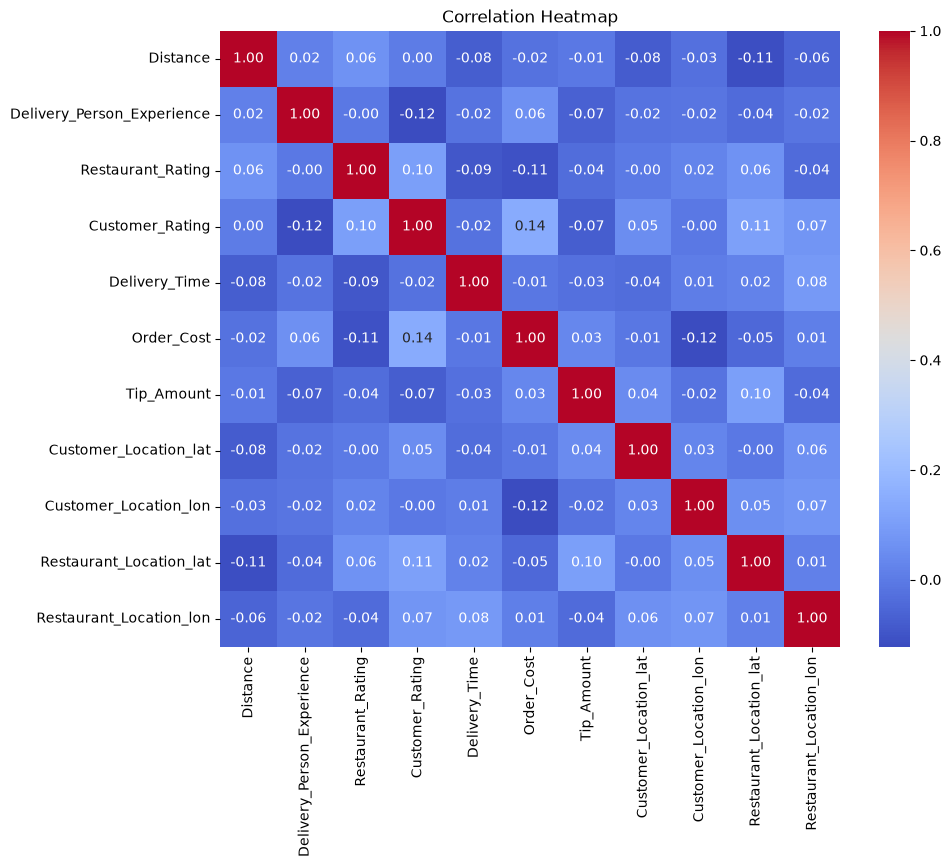

correlation with Delivery_Time:
Delivery_Time                 1.000000
Restaurant_Location_lon       0.083964
Restaurant_Location_lat       0.018548
Customer_Location_lon         0.008253
Order_Cost                   -0.009307
Delivery_Person_Experience   -0.019098
Customer_Rating              -0.021952
Tip_Amount                   -0.029154
Customer_Location_lat        -0.037146
Distance                     -0.075143
Restaurant_Rating            -0.091855
Name: Delivery_Time, dtype: float64


In [33]:
# correlation with Delivery_Time
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print("correlation with Delivery_Time:")
print(df[num_cols].corr()['Delivery_Time'].sort_values(ascending=False))


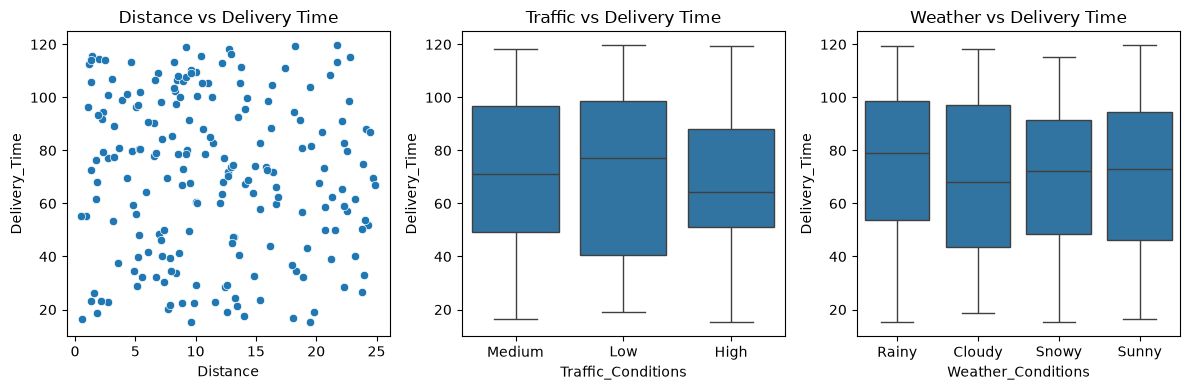

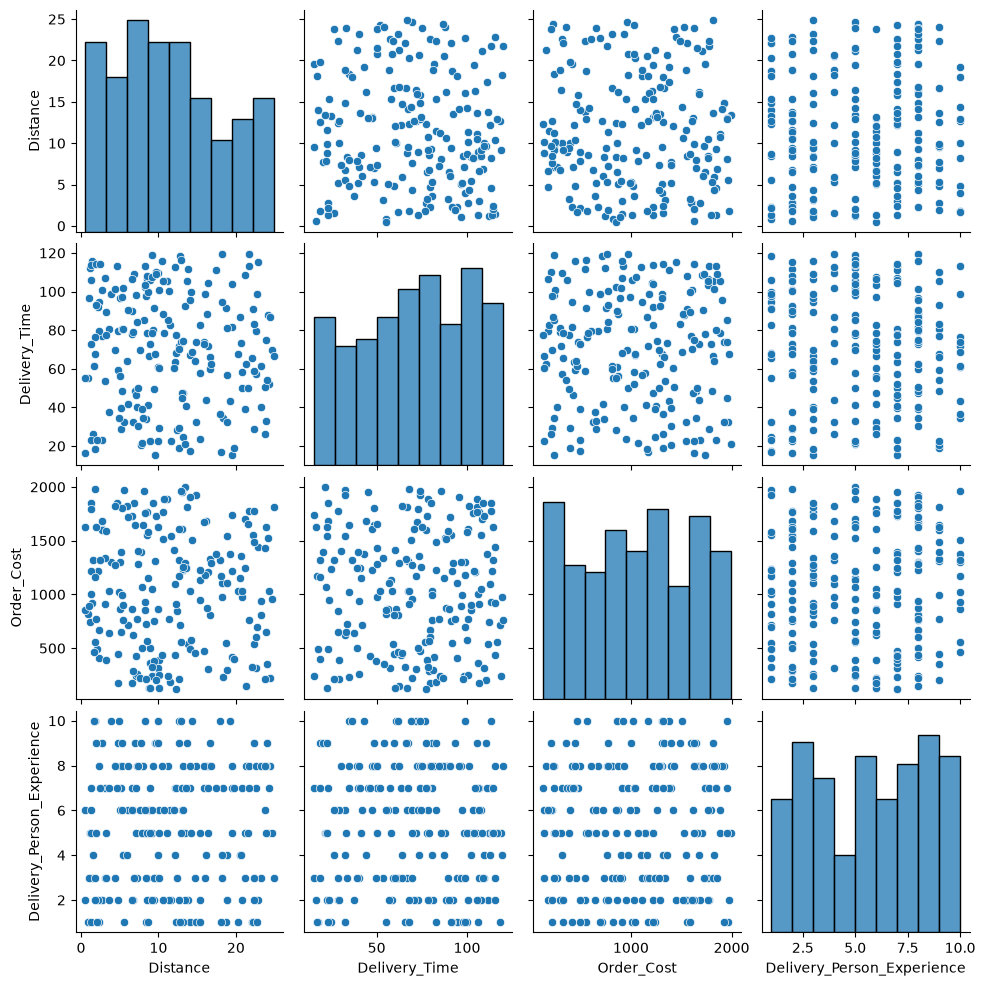

In [34]:
# quick looks - distance vs delivery time and some cats
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.scatterplot(x='Distance', y='Delivery_Time', data=df)
plt.title('Distance vs Delivery Time')

plt.subplot(1,3,2)
sns.boxplot(x='Traffic_Conditions', y='Delivery_Time', data=df)
plt.title('Traffic vs Delivery Time')

plt.subplot(1,3,3)
sns.boxplot(x='Weather_Conditions', y='Delivery_Time', data=df)
plt.title('Weather vs Delivery Time')

plt.tight_layout()
plt.show()

# pairplot for few important cols
sns.pairplot(df[['Distance','Delivery_Time','Order_Cost','Delivery_Person_Experience']])
plt.show()


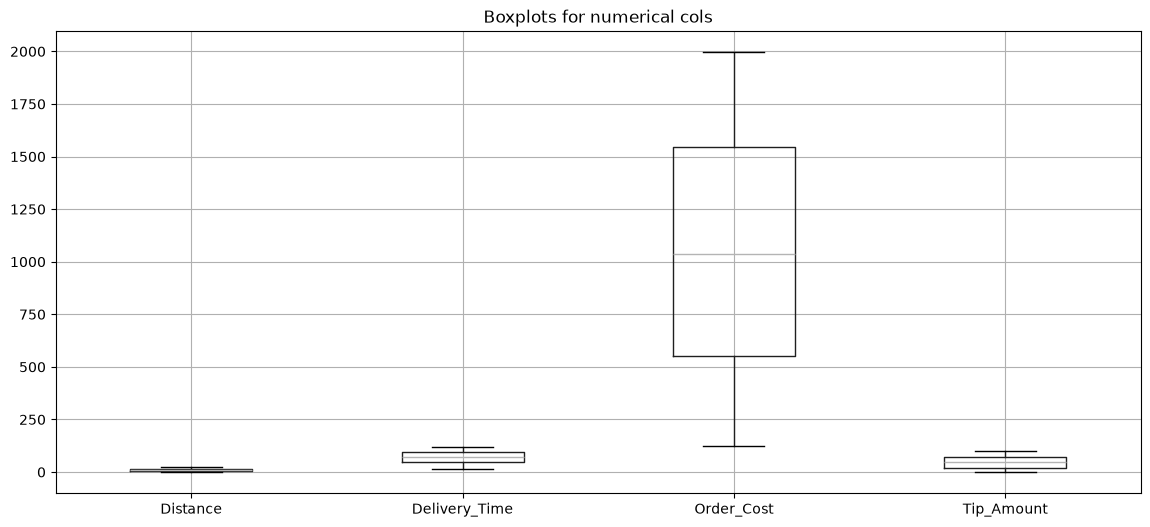

shape before: (200, 16)
shape after: (200, 16)


In [35]:
# outlier check using boxplots
plt.figure(figsize=(14,6))
df[['Distance','Delivery_Time','Order_Cost','Tip_Amount']].boxplot()
plt.title('Boxplots for numerical cols')
plt.show()

# removing extreme outliers with IQR (rough way)
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

print('shape before:', df.shape)
df = remove_outliers(df, 'Delivery_Time')
df = remove_outliers(df, 'Distance')
print('shape after:', df.shape)
df = df.reset_index(drop=True)


**Step 3 - Feature Engineering**

- Haversine distance from lat/lon (even though Distance already exists)
- Rush hour feature from Order_Time

In [36]:
# haversine formula to calc distance in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['Haversine_Distance'] = haversine(
    df['Customer_Location_lat'], df['Customer_Location_lon'],
    df['Restaurant_Location_lat'], df['Restaurant_Location_lon']
)

# rush hour - morning and evening usually busy
df['Rush_Hour'] = df['Order_Time'].apply(lambda x: 1 if x in ['Morning', 'Evening'] else 0)

print(df[['Distance','Haversine_Distance','Order_Time','Rush_Hour']].head(10))
print('\nrush hour counts:')
print(df['Rush_Hour'].value_counts())


   Distance  Haversine_Distance Order_Time  Rush_Hour
0      1.57          775.651198  Afternoon          0
1     21.32         1042.385597      Night          0
2      6.95          476.220706      Night          0
3     13.79          389.912629    Evening          1
4      6.72          806.505886      Night          0
5     10.00          392.168675    Evening          1
6      5.15          638.651532    Evening          1
7     22.57          849.297420    Evening          1
8     13.19          497.049109      Night          0
9     19.56          416.975418  Afternoon          0

rush hour counts:
Rush_Hour
0    104
1     96
Name: count, dtype: int64


#### **Phase 2: Classification using Naive Bayes, K-Nearest Neighbors, and Decision Tree**

1. **Naive Bayes Classifier**:

   * Apply the **Gaussian Naive Bayes** classifier, which is suitable for continuous features, to predict the binary class of delivery status (fast or delayed).  
   * **Evaluation Metrics:** Accuracy, Confusion Matrix, Precision, Recall, F1-score.  
2. **K-Nearest Neighbors (KNN)**:

   * Use the **KNN classifier** for the binary classification of fast vs. delayed deliveries.  
   * **Hyperparameter Tuning:** Find the optimal value for the number of neighbors (K) using cross-validation.  
   * **Evaluation Metrics:** Accuracy, Confusion Matrix, Precision, Recall, F1-score.  
3. **Decision Tree**:

   * Train a **Decision Tree classifier** to model the classification of delivery times.  
   * **Hyperparameter Tuning:** Prune the tree to avoid overfitting using `max_depth` and `min_samples_split`.  
   * **Evaluation Metrics:** Accuracy, Confusion Matrix, Precision, Recall, F1-score.

In [40]:
# create binary target - Fast=0, Delayed=1 based on median
median_time = df['Delivery_Time'].median()
print('median delivery time:', median_time)

df_clf = df.copy()
df_clf['Delayed'] = (df_clf['Delivery_Time'] > median_time).astype(int)
print(df_clf['Delayed'].value_counts())


X_clf = df_clf.drop(columns=['Delivery_Time','Delayed','Haversine_Distance',
                             'Customer_Location_lat','Customer_Location_lon',
                             'Restaurant_Location_lat','Restaurant_Location_lon'])
y_clf = df_clf['Delayed']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

median delivery time: 72.775
Delayed
0    100
1    100
Name: count, dtype: int64


In [43]:
df_clf.columns

Index(['Distance', 'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'Customer_Location_lat',
       'Customer_Location_lon', 'Restaurant_Location_lat',
       'Restaurant_Location_lon', 'Haversine_Distance', 'Rush_Hour',
       'Delayed'],
      dtype='str')

In [44]:
clf_cat_cols = Xc_train.select_dtypes(include=['object', 'string', 'str']).columns.tolist()
clf_num_cols = Xc_train.select_dtypes(include=['number']).columns.tolist()

print('clf cat:', clf_cat_cols)
print('clf num:', clf_num_cols)

def make_transformer():
    return ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), clf_cat_cols),
        ('st', StandardScaler(), clf_num_cols),
    ], remainder='drop')

knn_pipe = Pipeline([
    ('transformer', make_transformer()),
    ('classifier', KNeighborsClassifier()),
])

naive_bayes_pipe = Pipeline([
    ('transformer', make_transformer()),
    ('classifier', GaussianNB()),
])

decision_tree_pipe = Pipeline([
    ('transformer', make_transformer()),
    ('classifier', DecisionTreeClassifier()),
])

clf cat: ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
clf num: ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Rush_Hour']


In [47]:
knn_pipe.fit(Xc_train, yc_train)
naive_bayes_pipe.fit(Xc_train, yc_train)
decision_tree_pipe.fit(Xc_train, yc_train)

prediction_res = []

knn_pred = knn_pipe.predict(Xc_test)
naive_bayes_pred = naive_bayes_pipe.predict(Xc_test)
decision_tree_pred = decision_tree_pipe.predict(Xc_test)

prediction_res.append({"model": "KNN", "predictions": knn_pred})
prediction_res.append({"model": "Naive Bayes", "predictions": naive_bayes_pred})
prediction_res.append({"model": "Decision Tree", "predictions": decision_tree_pred})

In [49]:
prediction_res

[{'model': 'KNN',
  'predictions': array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
         1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1])},
 {'model': 'Naive Bayes',
  'predictions': array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
         0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1])},
 {'model': 'Decision Tree',
  'predictions': array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
         1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0])}]

#### **Phase 3: Reporting and Insights**

**Step 6 - Model Evaluation and Comparison**

/var/folders/3k/2r4fckl56zxdspgzm1tw5pdw0000gn/T/ipykernel_53960/2445106521.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


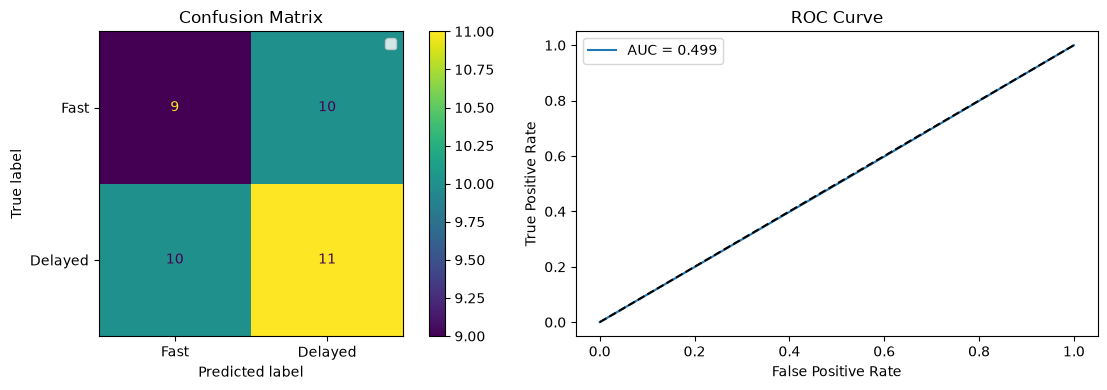

/var/folders/3k/2r4fckl56zxdspgzm1tw5pdw0000gn/T/ipykernel_53960/2445106521.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


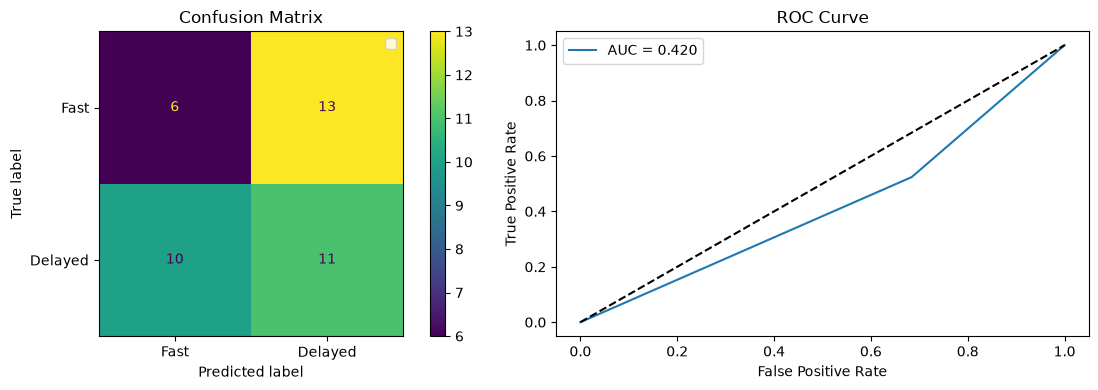

/var/folders/3k/2r4fckl56zxdspgzm1tw5pdw0000gn/T/ipykernel_53960/2445106521.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


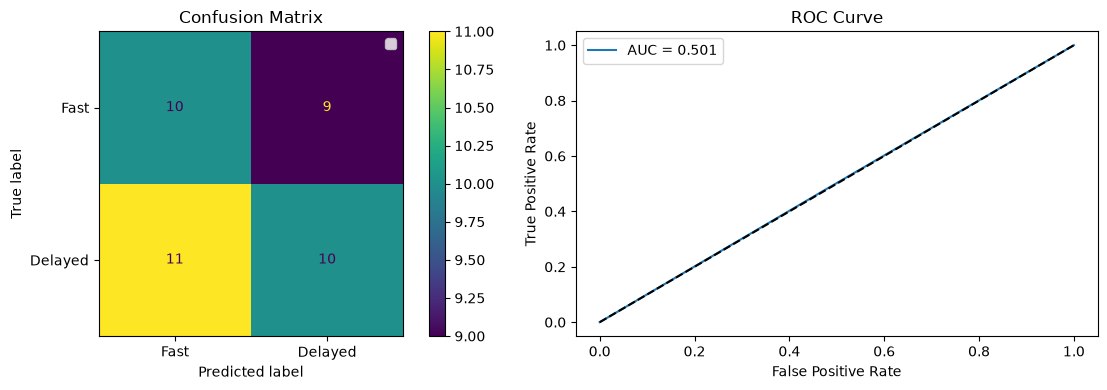

In [50]:
def plot_confusion_matrix(y_true, y_pred, display_labels=['Fast','Delayed']):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=display_labels, ax=ax[0]
    )
    ax[0].set_title('Confusion Matrix')
    ax[0].legend()
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    ax[1].plot([0,1],[0,1],'k--')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('ROC Curve')
    ax[1].legend()
    plt.tight_layout()
    plt.show()


for res in prediction_res:
    plot_confusion_matrix(yc_test, res['predictions'])

In [ ]:
# compare models
for res in prediction_res:
    print(f'{res["model"]}:')
    print(f'  Accuracy: {accuracy_score(yc_test, res["predictions"]):.3f}')
    print(f'  Precision: {precision_score(yc_test, res["predictions"]):.3f}')
    print(f'  Recall: {recall_score(yc_test, res["predictions"]):.3f}')
    print(f'  F1-score: {f1_score(yc_test, res["predictions"]):.3f}')

KNN:
  Accuracy: 0.500
  Precision: 0.524
  Recall: 0.524
  F1-score: 0.524
Naive Bayes:
  Accuracy: 0.425
  Precision: 0.458
  Recall: 0.524
  F1-score: 0.489
Decision Tree:
  Accuracy: 0.500
  Precision: 0.526
  Recall: 0.476
  F1-score: 0.500


**Step 7 - Actionable Insights / Final Report (rough notes)**

**Dataset & preprocessing**
- 200 rows, no missing values
- Parsed lat/lon; Haversine + Rush_Hour features
- Binary target: Delayed=1 if Delivery_Time > median, else Fast=0
- One-hot cats + StandardScaler nums inside Pipeline / ColumnTransformer (using Xc_train columns only)

**Model comparison (Fast vs Delayed)**
- Gaussian Naive Bayes, KNN, Decision Tree
- Metrics on test set are all near chance (~0.43–0.50 accuracy) — weak feature signal in this CSV
- **KNN** slightly best here; **Decision Tree** more interpretable; **Naive Bayes** weakest baseline
- Confusion matrices + ROC plots above for each model

**Strengths / weaknesses (short)**
- NB: fast & simple, but independence assumption hurts
- KNN: flexible, needs good scaling / choice of K
- Tree: readable rules, easy to overfit without pruning

**Recommendation**
- For score on this data: lean KNN (tune K with CV next)
- For ops explainability: pruned Decision Tree
- Better data (prep time, live traffic) will help more than swapping models

**Ops ideas**
1. Optimize routes in High traffic / long Distance
2. Staff more in Rush_Hour (Morning & Evening)
3. Prefer Bike/Car in bad weather
4. Extra training for low-experience riders

**Full detailed report:** see `Final_Report.md`

